# WEC Farm — EDA
Initial exploration: load all 4 datasets, verify the `Total_Power` ≈ sum-of-powers relationship, inspect the q-factor (`qW`) distribution, and visualize individual layouts.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR = Path("../data/WEC")

FILES = {
    "Perth_49":   ("Perth",   49),
    "Perth_100":  ("Perth",  100),
    "Sydney_49":  ("Sydney",  49),
    "Sydney_100": ("Sydney", 100),
}

dfs = {}
for key, (loc, n) in FILES.items():
    path = DATA_DIR / f"WEC_{loc}_{n}.csv"
    dfs[key] = pd.read_csv(path)
    print(f"{key:12s}  shape={dfs[key].shape}  missing={dfs[key].isna().sum().sum()}")

Perth_49      shape=(36043, 149)  missing=0
Perth_100     shape=(7277, 302)  missing=0
Sydney_49     shape=(17964, 149)  missing=0
Sydney_100    shape=(2318, 302)  missing=0


## 1  Verify `Total_Power` ≈ sum of per-device powers

Compute the residual `Total_Power − Σ(Power_i)` for every row in every file.

In [12]:
dfs["Perth_49"].head()

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
0,600.0000,0.0000,546.1600,37.5000,489.7900,74.8800,432.4700,112.0500,650.0000,0.0000,...,88867.9200,98844.3000,101283.5900,98934.6300,101624.5800,100915.0300,99625.6800,96704.3400,0.8700,4102461.4300
1,593.0000,12.0000,546.1600,37.5000,489.7900,74.8800,432.4700,112.0500,644.0000,8.0000,...,88896.5500,98759.7900,101346.0700,98873.5900,101629.0100,100934.5300,99606.1300,96718.3900,0.8700,4103361.4100
2,593.0000,12.0000,546.1600,37.5000,489.7900,74.8800,432.4700,112.0500,644.0000,8.0000,...,88919.8300,98746.6800,101346.1500,98875.5700,101618.3200,100941.0000,99611.3500,96719.1400,0.8700,4103680.4400
3,593.0000,12.0000,546.1600,37.5000,489.7900,74.8800,432.4700,112.0500,644.0000,8.0000,...,88855.1400,98760.9600,101338.5900,98971.5800,101632.2800,100943.5900,99589.2500,96735.0400,0.8700,4105661.0600
4,200.0000,0.0000,146.1700,37.5300,89.7600,74.9300,32.4000,112.1800,400.0000,0.0000,...,88005.3000,98630.2400,100432.7300,98803.0100,101064.4800,100948.3800,99028.8700,96286.7100,0.7900,3752648.7700


In [2]:
residual_stats = []

for key, (_, n) in FILES.items():
    df = dfs[key]
    power_cols = [f"Power{i}" for i in range(1, n + 1)]
    residual = df["Total_Power"] - df[power_cols].sum(axis=1)
    residual_stats.append({
        "dataset": key,
        "residual_mean": residual.mean(),
        "residual_std": residual.std(),
        "residual_max_abs": residual.abs().max(),
        "residual_rel_pct": (residual.abs() / df["Total_Power"]).mean() * 100,
    })

stats_df = pd.DataFrame(residual_stats).set_index("dataset")
pd.options.display.float_format = "{:.4f}".format
print(stats_df.to_string())

            residual_mean  residual_std  residual_max_abs  residual_rel_pct
dataset                                                                    
Perth_49        -138.4861      689.1281         4072.2300            0.0033
Perth_100         -0.0472        1.8073           87.7300            0.0000
Sydney_49        -70.5883      263.1933         2732.5900            0.0028
Sydney_100        14.0417      243.3052         2621.2600            0.0009


## 2  Q-factor (`qW`) distribution

One histogram per dataset; reference lines at `qW = 1` (no interaction effect) and the dataset mean.

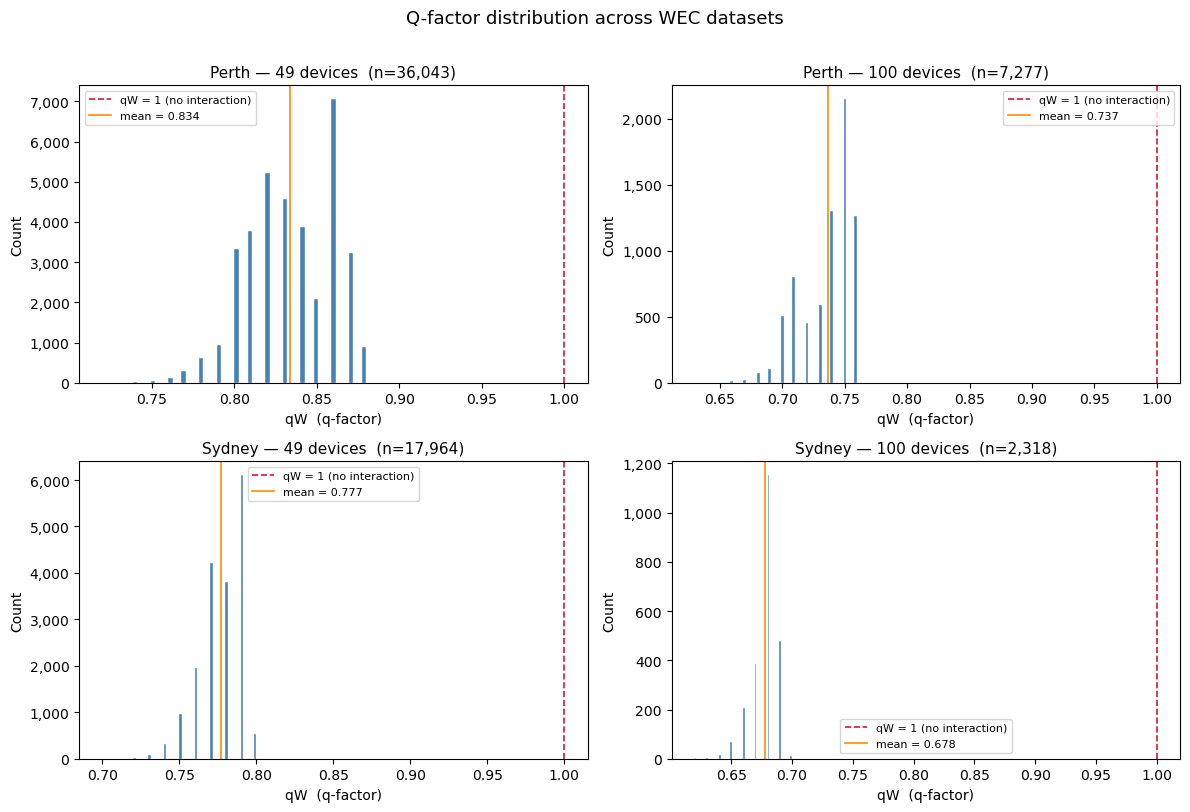

Saved → figures/qW_distributions.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()

for ax, (key, (loc, n)) in zip(axes, FILES.items()):
    qw = dfs[key]["qW"]
    mean_qw = qw.mean()

    ax.hist(qw, bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.axvline(1.0,     color="crimson",   linestyle="--", linewidth=1.2, label="qW = 1 (no interaction)")
    ax.axvline(mean_qw, color="darkorange", linestyle="-",  linewidth=1.2, label=f"mean = {mean_qw:.3f}")

    ax.set_title(f"{loc} — {n} devices  (n={len(qw):,})", fontsize=11)
    ax.set_xlabel("qW  (q-factor)")
    ax.set_ylabel("Count")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend(fontsize=8)

fig.suptitle("Q-factor distribution across WEC datasets", fontsize=13, y=1.01)
plt.tight_layout()

fig_dir = Path("../figures")
fig_dir.mkdir(exist_ok=True)
fig.savefig(fig_dir / "qW_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/qW_distributions.png")

In [4]:
# Summary table for qW
qw_summary = pd.DataFrame([
    {
        "dataset": key,
        "min": dfs[key]["qW"].min(),
        "p5":  dfs[key]["qW"].quantile(0.05),
        "mean": dfs[key]["qW"].mean(),
        "median": dfs[key]["qW"].median(),
        "p95": dfs[key]["qW"].quantile(0.95),
        "max": dfs[key]["qW"].max(),
        "pct_above_1": (dfs[key]["qW"] > 1).mean() * 100,
    }
    for key in FILES
]).set_index("dataset")

pd.options.display.float_format = "{:.4f}".format
print(qw_summary.to_string())

              min     p5   mean  median    p95    max  pct_above_1
dataset                                                           
Perth_49   0.7200 0.7900 0.8338  0.8300 0.8700 0.8800       0.0000
Perth_100  0.6300 0.7000 0.7366  0.7400 0.7600 0.7600       0.0000
Sydney_49  0.7000 0.7500 0.7769  0.7800 0.7900 0.8000       0.0000
Sydney_100 0.6200 0.6600 0.6776  0.6800 0.6900 0.7000       0.0000


## 3  Layout visualizer

`plot_layout(df, layout_idx, normalize=True)` — scatter plot of device positions colored by power output.

- `normalize=True` (default): color = fraction of layout mean; highlights which buoys under/over-perform relative to the rest of this layout.
- `normalize=False`: color = raw Watts; useful when absolute output matters.

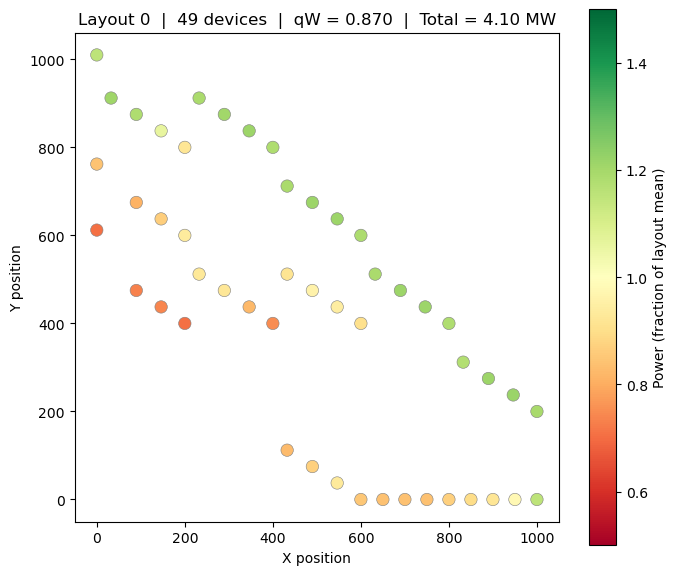

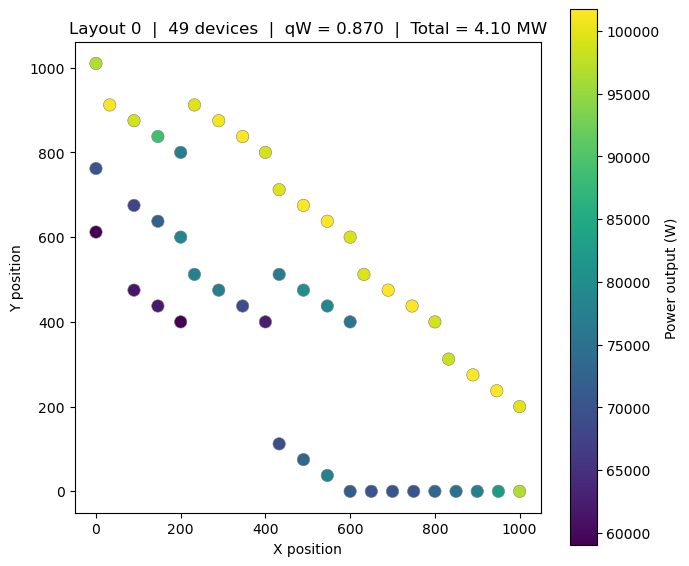

In [5]:
def plot_layout(df: pd.DataFrame, layout_idx: int, normalize: bool = True):
    """Scatter-plot one WEC farm layout, colored by per-device power."""
    n = sum(1 for c in df.columns if c.startswith("X") and c[1:].isdigit())
    row = df.iloc[layout_idx]

    x = row[[f"X{i}" for i in range(1, n + 1)]].values.astype(float)
    y = row[[f"Y{i}" for i in range(1, n + 1)]].values.astype(float)
    power = row[[f"Power{i}" for i in range(1, n + 1)]].values.astype(float)

    qw = row["qW"]
    total_mw = row["Total_Power"] / 1e6

    if normalize:
        c = power / power.mean()
        cmap, vmin, vmax = "RdYlGn", 0.5, 1.5
        cbar_label = "Power (fraction of layout mean)"
    else:
        c = power
        cmap, vmin, vmax = "viridis", power.min(), power.max()
        cbar_label = "Power output (W)"

    fig, ax = plt.subplots(figsize=(7, 7))
    sc = ax.scatter(x, y, c=c, cmap=cmap, vmin=vmin, vmax=vmax,
                    s=80, edgecolors="grey", linewidths=0.4)
    plt.colorbar(sc, ax=ax, label=cbar_label, shrink=0.8)

    ax.set_aspect("equal")
    ax.set_xlabel("X position")
    ax.set_ylabel("Y position")
    ax.set_title(
        f"Layout {layout_idx}  |  {n} devices  |  "
        f"qW = {qw:.3f}  |  Total = {total_mw:.2f} MW"
    )
    plt.tight_layout()
    return fig


# --- example calls ---
_ = plot_layout(dfs["Perth_49"], 0)                   # normalized (default)
_ = plot_layout(dfs["Perth_49"], 0, normalize=False)  # absolute watts

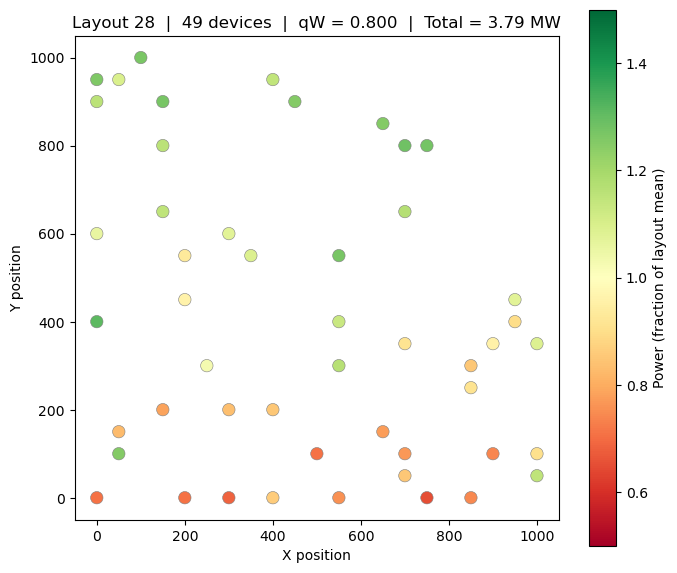

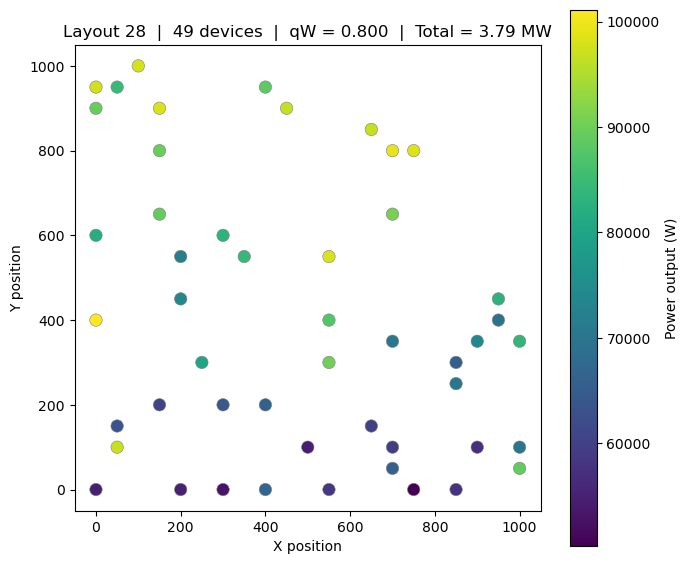

In [9]:
_ = plot_layout(dfs["Perth_49"], 28)                   # normalized (default)
_ = plot_layout(dfs["Perth_49"], 28, normalize=False)  # absolute watts